# 1. Setup
## 1.1 Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency


## 1.2 Importing CSV

In [2]:
# csv = "../data/healthcare_data.csv"
# csv = "../data/duplicates.csv"
# csv = "../data/non_duplicates.csv"
# csv = "../data/train.csv"
# csv = "../data/test.csv"

# csv = "../data/recoded.csv"
# csv = "../data/recoded_duplicates.csv"
# csv = "../data/recoded_non_duplicates.csv"
csv = "../data/recoded_train.csv"
# csv = "../data/recoded_test.csv"
df = pd.read_csv(csv)
df.head()

,gender,age,has_hypertension,has_heart_disease,marital_status,employment_type,residence,glucose_level,bmi_value,smoking_habit,stroke_event,age_group,risk_score,high_glucose,bmi_category,lifestyle_risk
0,Male,27.0,No,No,No,working,Rural,63.53,26.9,non_smoker,No,young,0,No,overweight,low
1,Male,51.0,No,No,Yes,working,Rural,232.64,45.2,non_smoker,No,middle,0,Yes,obese,low
2,Female,22.0,No,No,No,government,Urban,123.23,21.3,unknown,No,young,0,No,normal,low
3,Female,20.0,No,No,No,working,Urban,80.27,27.9,non_smoker,No,young,0,No,overweight,low
4,Male,52.0,No,No,Yes,working,Rural,191.66,26.1,current_smoker,No,middle,0,Yes,overweight,low


## 1.3 Overview of dataset

In [19]:
num_cols = ["age", "glucose_level", "bmi_value", "risk_score"]
cat_cols = ["gender", "age_group", "has_hypertension", "has_heart_disease", "marital_status", "employment_type", "residence", "high_glucose", "bmi_category", "smoking_habit", "lifestyle_risk", "stroke_event"]
ordinal_cats = ["age_group", "bmi_category", "lifestyle_risk"]
nominal_cats = [col for col in cat_cols if col not in ordinal_cats]

In [4]:
summary_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

display(summary_table)

,Missing Values,Unique Values
gender,0,2
age,0,104
has_hypertension,0,2
has_heart_disease,0,2
marital_status,0,2
employment_type,0,3
residence,0,2
glucose_level,0,3353
bmi_value,160,401
smoking_habit,0,4


In [5]:
combined_counts = pd.concat(
    {
        col: df[col].value_counts()
        for col in cat_cols
    },
    axis=0
)

display(pd.DataFrame(combined_counts))

count
gender            Female           2390
                  Male             1698
age_group         middle           1778
                  young            1206
                  senior           1104
has_hypertension  No               3701
                  Yes               387
has_heart_disease No               3867
                  Yes               221
marital_status    Yes              2690
                  No               1398
employment_type   working          2992
                  other             564
                  government        532
residence         Urban            2075
                  Rural            2013
high_glucose      No               3415
                  Yes               673
bmi_category      obese            1709
                  overweight       1144
                  normal            966
                  underweight       269
smoking_habit     non_smoker       1495
                  unknown          1255
                  ex_smoker         719
                  current_smoker    619
lifestyle_risk    low              3065
                  medium            719
                  high              304
stroke_event      No               3893
                  Yes               195

In [6]:
display(df[num_cols].describe())

,age,glucose_level,bmi_value,risk_score
count,4088.000000,4088.000000,3928.000000,4088.000000
mean,43.343229,106.483708,28.888493,0.148728
std,22.636856,45.670287,7.685995,0.389353
min,0.080000,55.120000,11.300000,0.000000
25%,25.000000,77.237500,23.600000,0.000000
50%,45.000000,91.835000,28.100000,0.000000
75%,61.000000,114.320000,33.000000,0.000000
max,82.000000,271.740000,78.000000,2.000000


# 2 Visualization
## 2.1 Configuring plotting parameters

In [7]:
sns.set_theme(style="white")

plt.rcParams.update({
    'font.family': 'RobotoMono Nerd Font Mono',
    'font.size': 20,
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'figure.titlesize': 20,

    # Turn ticks ON
    'xtick.bottom': True,
    'ytick.left': True,

    # Tick direction & size
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 8,
    'ytick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.minor.size': 4,

    # Minor ticks visibility (important)
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,

    # Grid
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.axisbelow': True,
})



## 2.2 Configuring Axis

In [8]:
def style_ax(
    ax,
    minor_ticks=True,
    show_top=False,
    show_right=False,
    major_grid=True,
    minor_grid=True,
    major_grid_style=None,
    minor_grid_style=None
):

    # Default grid styles
    if major_grid_style is None:
        major_grid_style=dict(linestyle='--', linewidth=0.8, alpha=0.4)


    if minor_grid_style is None:
        minor_grid_style=dict(linestyle=':', linewidth=0.5, alpha=0.3)

    # Minor ticks
    if minor_ticks:
        ax.minorticks_on()

    # Tick visibility
    ax.tick_params(
        axis='both',
        which='both',
        top=show_top,
        right=show_right
    )

    # Major grid
    if major_grid:
        ax.grid(True, which='major', **major_grid_style)

    # Minor grid
    if minor_grid:
        ax.grid(True, which='minor', **minor_grid_style)

    return ax



## 2.3 Setting up save figure function

In [9]:
import os

def save_figure(
    fig,
    x_label=None,
    y_label=None,
    other_label=None,
    save_path=None,
    save_format="png",
    dpi=300,
    transparent=False,
    to_title=lambda s: str(s).title()
):
   
    if not save_path:
        return None

    os.makedirs(save_path, exist_ok=True)

    filename = f"{to_title(x_label)} {('VS ' + to_title(y_label)) if y_label else to_title(other_label)}"

    if transparent:
        filename += " Transparent"

    full_path = os.path.join(save_path, f"{filename}.{save_format}")

    fig.savefig(
        full_path,
        format=save_format,
        dpi=dpi,
        bbox_inches="tight",
        transparent=transparent
    )

    return full_path

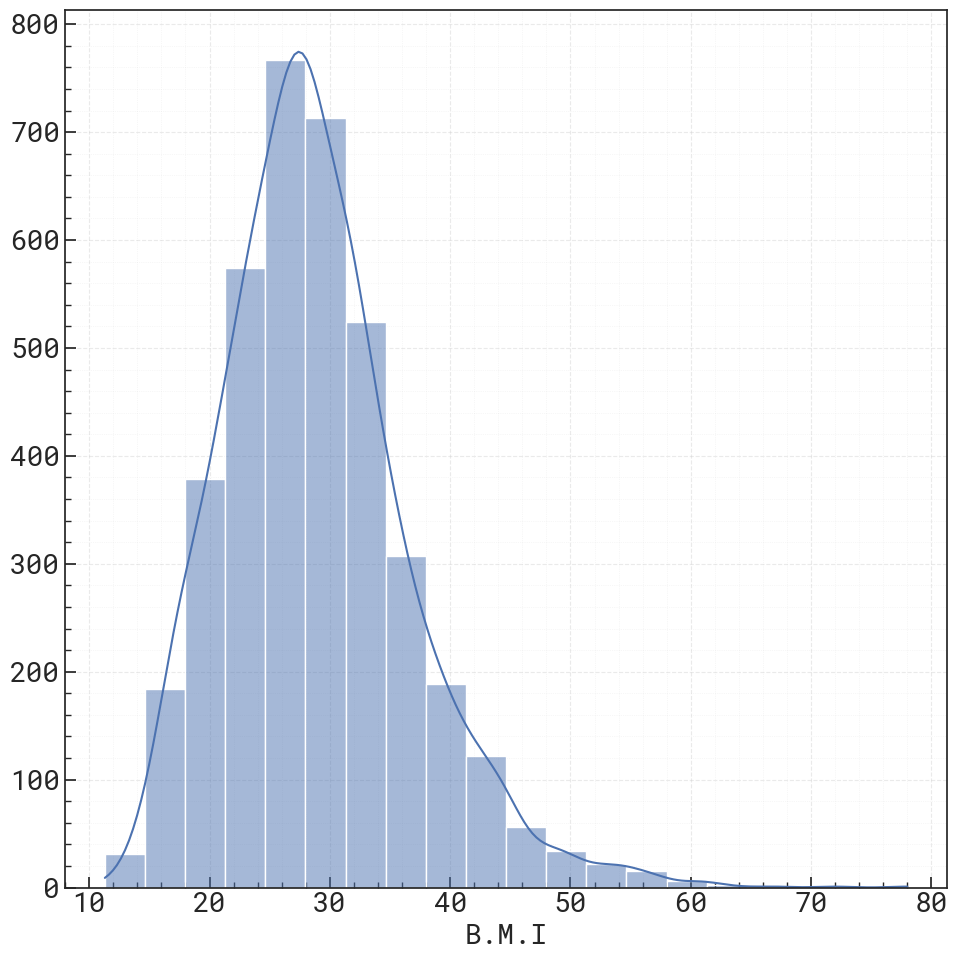

In [11]:
fig, ax = plt.subplots(figsize=(10,10))

sns.histplot(data=df, x="bmi_value", bins=20, kde=True, ax=ax)


style_ax(
    ax,
    minor_ticks=True,
    show_top=False,
    show_right=False,
    major_grid=True,
    minor_grid=True
)
ax.set_xlabel("B.M.I")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

# save_figure(
#     fig,
#     x_label = "B.M.I.",
#     other_label="histogram",
#     save_path="../exports/"
# )

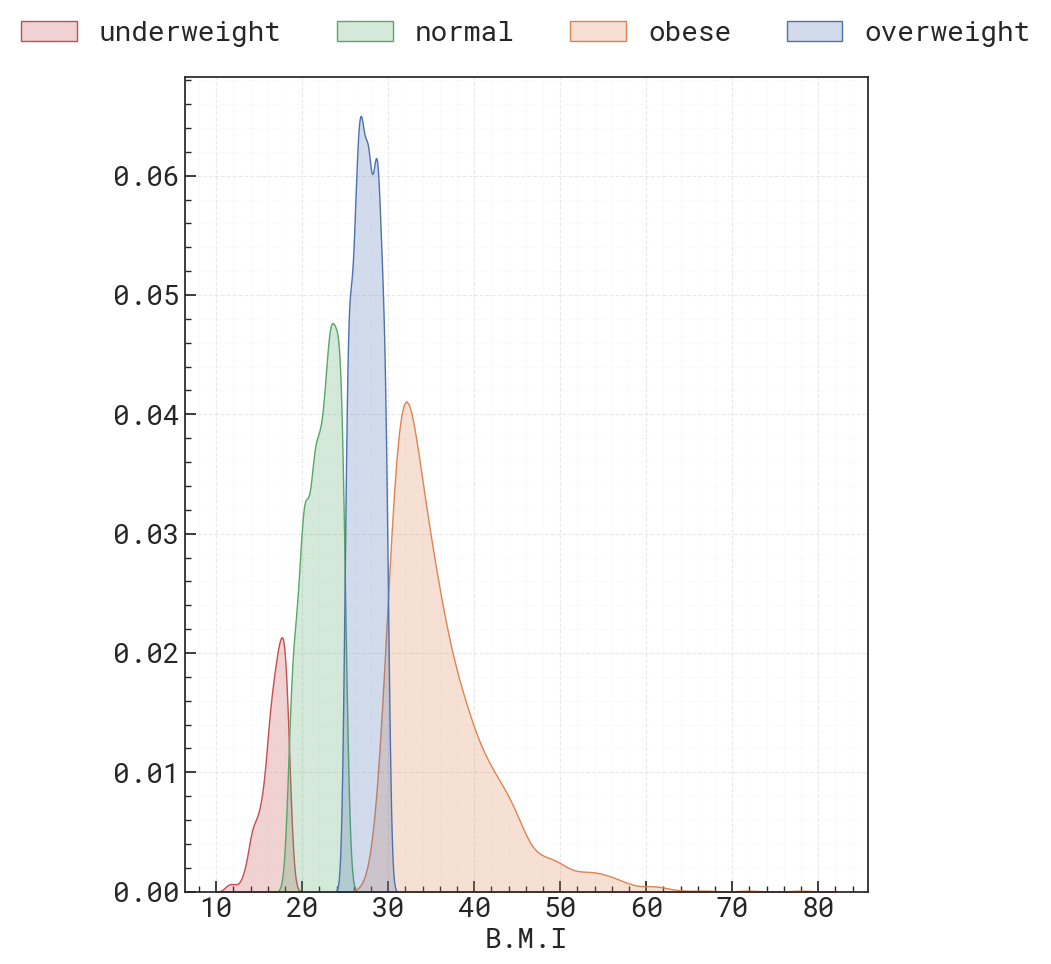

In [10]:
fig, ax = plt.subplots(figsize=(10,10))

sns.kdeplot(data=df, x="bmi_value", hue="bmi_category", fill=True, ax=ax)

style_ax(
    ax,
    minor_ticks=True,
    show_top=False,
    show_right=False,
    major_grid=True,
    minor_grid=True
)
ax.set_xlabel("B.M.I")
ax.set_ylabel("")

ax.legend(
    labels = [t.get_text() for t in ax.legend_.texts][::-1],
    loc='upper center',
    bbox_to_anchor=(0.5, 1.10),
    ncol=4,
    frameon=False
)


plt.tight_layout()
plt.show()

# save_figure(
#     fig,
#     x_label = "B.M.I.",
#     other_label="kde",
#     save_path="../exports/"
# )

In [18]:
mean_bmi = df.groupby(['bmi_category', 'gender'])['bmi_value'].mean().round(2)
display(pd.DataFrame(mean_bmi))

bmi_value
bmi_category gender           
normal       Female      22.22
             Male        22.04
obese        Female      37.06
             Male        35.22
overweight   Female      27.43
             Male        27.47
underweight  Female      16.56
             Male        16.72

In [19]:
mean_bmi = df.groupby(['bmi_category', 'gender'])['bmi_value'].median().round(2)
display(pd.DataFrame(mean_bmi))

bmi_value
bmi_category gender           
normal       Female       22.4
             Male         22.2
obese        Female       35.2
             Male         33.6
overweight   Female       27.5
             Male         27.5
underweight  Female       17.0
             Male         16.9

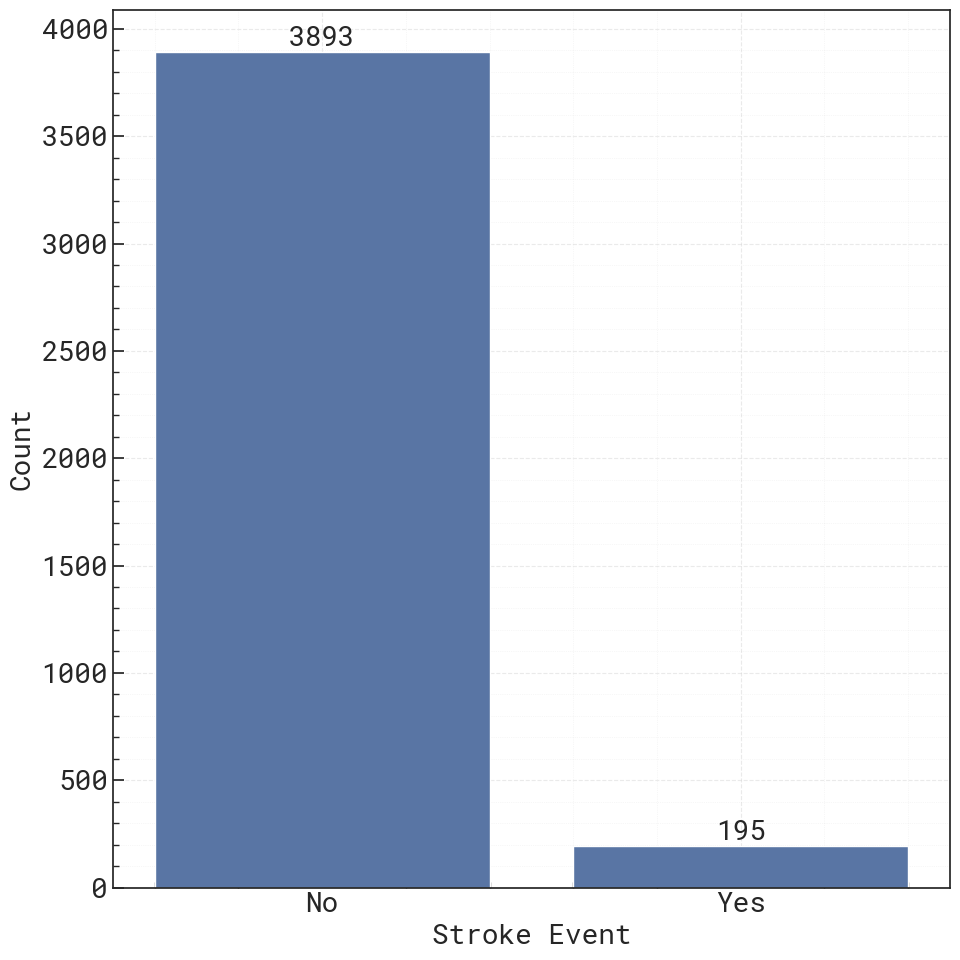

'../exports/Stroke Event Distribution.png'

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))

sns.countplot(x='stroke_event', data=df, ax=ax)

style_ax(
    ax,
    minor_ticks=True,
    show_top=False,
    show_right=False,
    major_grid=True,
    minor_grid=True
)
ax.set_xlabel("Stroke Event")
ax.set_ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

# save_figure(
#     fig,
#     x_label = "Stroke Event",
#     other_label="Distribution",
#     save_path="../exports/"
# )

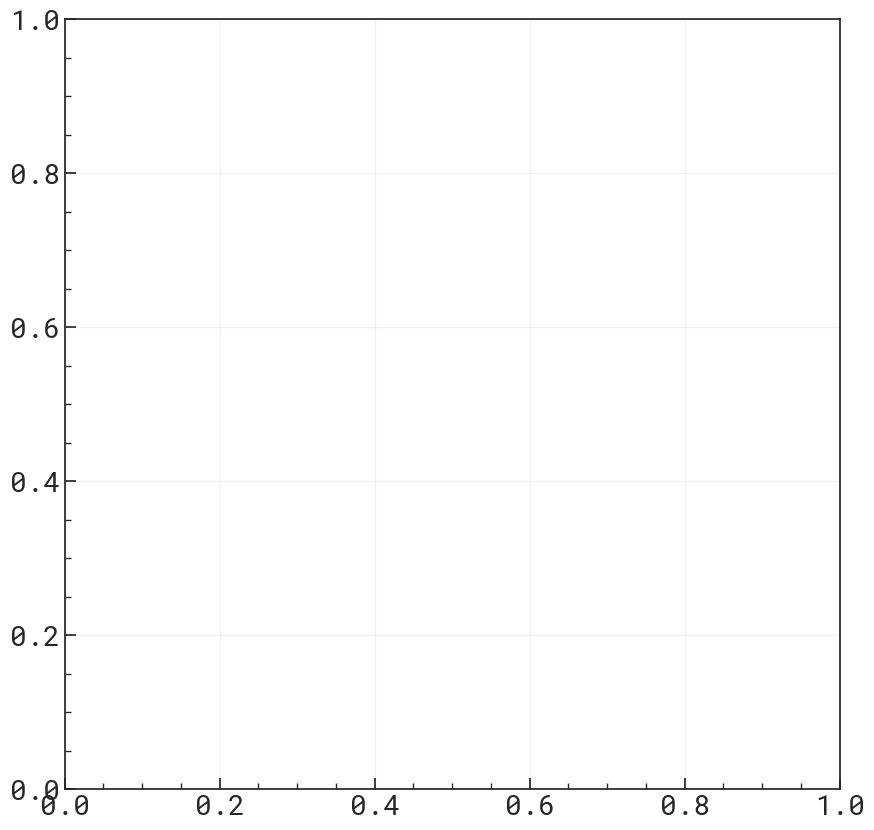

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))






In [ ]:
corr_matrix = df.corr()

# Plot the heatmap, focusing on how everything correlates to 'stroke_event'
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
            annot=True, # Keep False to avoid cluttering a 20x20 grid
            linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [15]:
combined_table_pct = pd.concat(
    {
        col: pd.crosstab(df[col], df["TARGET"])
        for col in cat_cols if col != "TARGET"
    },
    axis=0
).round(2)

display(combined_table_pct)

chi2_summary = []

for col in [c for c in cat_cols if c != "TARGET"]:
    contingency_table = pd.crosstab(df[col], df['TARGET'])
    
    stat, p, dof, expected = chi2_contingency(contingency_table)
    
    chi2_summary.append({
        'Feature': col,
        'Chi-Square Statistic': round(stat, 4),
        'P-value': round(p, 4),
        'Degrees of Freedom': dof,
        'Significant (α=0.05)': 'Yes' if p < 0.05 else 'No'
    })

chi2_results_df = pd.DataFrame(chi2_summary).sort_values(by='P-value')

display(chi2_results_df.style.background_gradient(subset=['P-value'], cmap='Reds_r'))


KeyError: 'TARGET'

The table shows which categorical features are statistically "linked" to the `TARGET`.


`INCOME_TYPE`, `REALITY`, `FAMILY_TYPE`, and `GENDER` all have p-values $< 0.05$.